# 301b — Combined T/S known-error interaction analysis for depletion_q

This notebook tests what happens when **transmissivity (T)** and **storage (S)** are perturbed together.

It builds on `301a`, where T and S were perturbed one at a time. Here, the goal is to ask:

> Are the combined T/S effects approximately additive, or do T and S interact in a way that amplifies or dampens streamflow uncertainty?

The workflow keeps the baseline `depletion_q` Pareto pumping designs fixed and re-evaluates those designs under combined T/S corner scenarios.


## 1. Imports, helper reload, and user controls

Recommended workflow:

1. Run a small test with `N_TEST_MEMBERS = 10`.
2. Run the full front with `N_TEST_MEMBERS = None` and `RERUN_REEVALUATION = True`.
3. After the full cache exists, use `RERUN_REEVALUATION = False`.


In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()
import uncertainty_project_helpers_depletion_q as up

print("Helper imported from:", up.__file__)
print("Helper version:", up.HELPER_VERSION)

PROJECT_DIR = up.find_lpr_pycap_opt_dir()
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Uncertainty_Project_depletion_q"
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"
CACHE_DIR = NOTEBOOK_DIR / "cached_reevaluations"
OUTPUT_DIR = PROJECT_OUTPUT_DIR / "301b_combined_T_storage_known_error_depletion_q"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "depletion_q_baseline_0.0_1.0_0.01"

T_FACTORS = (0.9, 1.0, 1.1)
S_FACTORS = (0.9, 1.0, 1.1)

RERUN_REEVALUATION = False
N_TEST_MEMBERS = None

CACHE_FILE = CACHE_DIR / "301b_depletion_q_combined_T_storage_reevaluation_v1.csv"
ERROR_CACHE_FILE = CACHE_DIR / "301b_depletion_q_combined_T_storage_reevaluation_errors_v1.csv"

up.apply_plot_style()

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)
print("T_FACTORS:", T_FACTORS)
print("S_FACTORS:", S_FACTORS)
print("RERUN_REEVALUATION:", RERUN_REEVALUATION)
print("N_TEST_MEMBERS:", N_TEST_MEMBERS)


Helper imported from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-23_depletion_q_304_v2_clean_member_labels_and_reliability_plot
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/cached_reevaluations/301b_depletion_q_combined_T_storage_reevaluation_v1.csv
T_FACTORS: (0.9, 1.0, 1.1)
S_FACTORS: (0.9, 1.0, 1.1)
RERUN_REEVALUATION: False
N_TEST_MEMBERS: None


## 2. Load the baseline model context and Pareto design population

This uses the same validated `depletion_q` baseline archive as Notebooks `300`, `301a`, `302`, and `303`.


In [2]:
context = up.load_depletion_q_context(RUN_NAME, project_dir=PROJECT_DIR)
archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(archive)
dv_df = up.load_decision_variable_population(context.run_dir)

if N_TEST_MEMBERS is not None:
    pareto_final = pareto_final.head(int(N_TEST_MEMBERS)).copy()

all_q_cols = up.get_q_columns(dv_df)
base_T = up.get_project_parameter_value(context.initial_dict_master, "transmissivity")
base_S = up.get_project_parameter_value(context.initial_dict_master, "storage")

print("Run directory:", context.run_dir)
print("Base T:", base_T)
print("Base S:", base_S)
print("Number of final front members selected:", len(pareto_final))
print("Decision-variable population shape:", dv_df.shape)
print("Number of decision-variable pumping columns from PEST control file:", len(context.decvar_q_cols))

display(pareto_final[["member", "generation", "obj_well", up.DEPLETION_OBS_NAME]].head())


Run directory: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01
Base T: 1700.0
Base S: 0.12
Number of final front members selected: 296
Decision-variable population shape: (8772, 327)
Number of decision-variable pumping columns from PEST control file: 86


,member,generation,obj_well,lpr:total_combined:bdpl
8495,152,50,17542.80,4.782580
8496,gen=36_member=6021_pso,50,7060.34,0.811083
8497,16,50,17265.50,4.489270
8498,130,50,17325.00,4.690710
8499,95,50,17459.90,4.701270


## 3. Define combined T/S corner scenarios

This uses five scenarios:

| Scenario | T factor | S factor |
|---|---:|---:|
| Baseline | 1.0 | 1.0 |
| T low, S low | 0.9 | 0.9 |
| T high, S high | 1.1 | 1.1 |
| T low, S high | 0.9 | 1.1 |
| T high, S low | 1.1 | 0.9 |

This is a targeted interaction test, not a full probability grid.


In [3]:
SCENARIOS = up.make_combined_T_storage_scenario_dict(
    t_factors=T_FACTORS,
    s_factors=S_FACTORS,
)
scenario_order = list(SCENARIOS.keys())
baseline_scenario = "baseline_T1_S1"
expected_rows = len(pareto_final) * len(SCENARIOS)

print("Scenarios:")
for key, value in SCENARIOS.items():
    print(key, value)
print("Expected rows:", expected_rows)


Scenarios:
baseline_T1_S1 {'T_factor': 1.0, 'S_factor': 1.0, 'scenario_label': 'Baseline T, baseline S'}
Tlow_Slow {'T_factor': 0.9, 'S_factor': 0.9, 'scenario_label': 'T -10%, S -10%'}
Thigh_Shigh {'T_factor': 1.1, 'S_factor': 1.1, 'scenario_label': 'T +10%, S +10%'}
Tlow_Shigh {'T_factor': 0.9, 'S_factor': 1.1, 'scenario_label': 'T -10%, S +10%'}
Thigh_Slow {'T_factor': 1.1, 'S_factor': 0.9, 'scenario_label': 'T +10%, S -10%'}
Expected rows: 1480


## 4. Re-evaluate the fixed baseline designs under combined T/S scenarios

In [4]:
if RERUN_REEVALUATION or not CACHE_FILE.exists():
    results_long, error_df = up.reevaluate_depletion_q_designs_combined_T_storage(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=all_q_cols,
        context=context,
        scenarios=SCENARIOS,
        progress_every=50,
    )
    results_long.to_csv(CACHE_FILE, index=False)
    up.write_error_cache(error_df, ERROR_CACHE_FILE)
else:
    results_long = pd.read_csv(CACHE_FILE)
    error_df = up.read_csv_if_not_empty(ERROR_CACHE_FILE)

if len(results_long) != expected_rows:
    raise ValueError(f"Cached or generated result has {len(results_long)} rows, but {expected_rows} rows were expected. Set RERUN_REEVALUATION = True to rebuild the cache for the current N_TEST_MEMBERS setting.")

print("Re-evaluation rows:", len(results_long))
print("Error rows:", len(error_df))
if not error_df.empty:
    display(error_df.head())

display(results_long.head())


Re-evaluation rows: 1480
Error rows: 0


,member,generation,scenario,scenario_label,T_factor,S_factor,T_value,S_value,base_T_value,base_S_value,archive_pumping_objective_cfs,pumping_objective_reeval_cfs,full_model_total_pumping_cfs,archive_depletion_cfs,depletion_cfs,streamflow_cfs
0,152,50,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,1700.0,0.12,1700.0,0.12,39.085358,39.085441,117.697971,4.782580,4.782582,3.817418
1,gen=36_member=6021_pso,50,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,1700.0,0.12,1700.0,0.12,15.730438,15.730429,94.342958,0.811083,0.811083,7.788917
2,16,50,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,1700.0,0.12,1700.0,0.12,38.467534,38.467529,117.080058,4.489270,4.489274,4.110726
3,130,50,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,1700.0,0.12,1700.0,0.12,38.600100,38.600146,117.212675,4.690710,4.690711,3.909289
4,95,50,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,1700.0,0.12,1700.0,0.12,38.900657,38.900681,117.513211,4.701270,4.701268,3.898732


## 5. Add baseline-relative changes and summary tables

In [5]:
baseline = results_long.loc[
    results_long["scenario"] == baseline_scenario,
    ["member", "depletion_cfs", "streamflow_cfs"]
].rename(
    columns={
        "depletion_cfs": "baseline_depletion_cfs",
        "streamflow_cfs": "baseline_streamflow_cfs",
    }
)

results_with_changes = results_long.merge(baseline, on="member", how="left")
results_with_changes["depletion_change_from_baseline_cfs"] = results_with_changes["depletion_cfs"] - results_with_changes["baseline_depletion_cfs"]
results_with_changes["streamflow_change_from_baseline_cfs"] = results_with_changes["streamflow_cfs"] - results_with_changes["baseline_streamflow_cfs"]
results_with_changes["absolute_streamflow_error_cfs"] = results_with_changes["streamflow_change_from_baseline_cfs"].abs()
results_with_changes["streamflow_shortfall_below_baseline_cfs"] = np.maximum(
    results_with_changes["baseline_streamflow_cfs"] - results_with_changes["streamflow_cfs"],
    0.0,
)

wide = results_with_changes.pivot_table(
    index="member",
    columns="scenario",
    values=[
        "T_factor",
        "S_factor",
        "pumping_objective_reeval_cfs",
        "depletion_cfs",
        "streamflow_cfs",
        "depletion_change_from_baseline_cfs",
        "streamflow_change_from_baseline_cfs",
        "absolute_streamflow_error_cfs",
        "streamflow_shortfall_below_baseline_cfs",
    ],
    aggfunc="first",
)
wide.columns = [f"{metric}__{scenario}" for metric, scenario in wide.columns]
wide = wide.reset_index()
wide[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS] = wide[f"pumping_objective_reeval_cfs__{baseline_scenario}"]

scenario_summary = (
    results_with_changes.groupby(["scenario", "scenario_label", "T_factor", "S_factor"], as_index=False)
    .agg(
        n_members=("member", "count"),
        mean_pumping_objective_cfs=("pumping_objective_reeval_cfs", "mean"),
        mean_depletion_cfs=("depletion_cfs", "mean"),
        min_depletion_cfs=("depletion_cfs", "min"),
        max_depletion_cfs=("depletion_cfs", "max"),
        mean_streamflow_cfs=("streamflow_cfs", "mean"),
        min_streamflow_cfs=("streamflow_cfs", "min"),
        max_streamflow_cfs=("streamflow_cfs", "max"),
        mean_depletion_change_from_baseline_cfs=("depletion_change_from_baseline_cfs", "mean"),
        mean_streamflow_change_from_baseline_cfs=("streamflow_change_from_baseline_cfs", "mean"),
        mean_absolute_streamflow_error_cfs=("absolute_streamflow_error_cfs", "mean"),
        max_absolute_streamflow_error_cfs=("absolute_streamflow_error_cfs", "max"),
        mean_streamflow_shortfall_below_baseline_cfs=("streamflow_shortfall_below_baseline_cfs", "mean"),
        max_streamflow_shortfall_below_baseline_cfs=("streamflow_shortfall_below_baseline_cfs", "max"),
    )
)

results_path = OUTPUT_DIR / "301b_combined_T_storage_reevaluation_long.csv"
wide_path = OUTPUT_DIR / "301b_combined_T_storage_reevaluation_wide.csv"
summary_path = OUTPUT_DIR / "301b_combined_T_storage_scenario_summary.csv"

results_with_changes.to_csv(results_path, index=False)
wide.to_csv(wide_path, index=False)
scenario_summary.to_csv(summary_path, index=False)

print("Saved:", results_path)
print("Saved:", wide_path)
print("Saved:", summary_path)

display(scenario_summary)


Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_reevaluation_long.csv
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_reevaluation_wide.csv
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_scenario_summary.csv


,scenario,scenario_label,T_factor,S_factor,n_members,mean_pumping_objective_cfs,mean_depletion_cfs,min_depletion_cfs,max_depletion_cfs,mean_streamflow_cfs,min_streamflow_cfs,max_streamflow_cfs,mean_depletion_change_from_baseline_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,Thigh_Shigh,"T +10%, S +10%",1.1,1.1,296,32.554952,2.748921,0.811083,4.782582,5.851079,3.817418,7.788917,2.306713e-16,-2.415485e-16,1.420785e-15,5.329071e-15,8.311670e-16,4.440892e-15
1,Thigh_Slow,"T +10%, S -10%",1.1,0.9,296,32.554952,3.105710,0.966045,5.284561,5.494290,3.315439,7.633955,3.567895e-01,-3.567895e-01,3.567895e-01,5.019792e-01,3.567895e-01,5.019792e-01
2,Tlow_Shigh,"T -10%, S +10%",0.9,1.1,296,32.554952,2.419350,0.673869,4.304726,6.180650,4.295274,7.926131,-3.295709e-01,3.295709e-01,3.295709e-01,4.778559e-01,0.000000e+00,0.000000e+00
3,Tlow_Slow,"T -10%, S -10%",0.9,0.9,296,32.554952,2.748921,0.811083,4.782582,5.851079,3.817418,7.788917,1.819115e-16,-1.800362e-16,1.500301e-15,5.329071e-15,8.401688e-16,5.329071e-15
4,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,296,32.554952,2.748921,0.811083,4.782582,5.851079,3.817418,7.788917,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


## 6. Load individual T-only and S-only results from 301a

The interaction calculation compares each combined scenario against an additive expectation from the individual-parameter effects.

For each member:

```text
expected additive streamflow change = T-only change + S-only change
interaction effect = combined change - expected additive change
```


In [6]:
DIR_301A_T = PROJECT_OUTPUT_DIR / "301_known_parameter_error_depletion_q" / "transmissivity"
DIR_301A_S = PROJECT_OUTPUT_DIR / "301_known_parameter_error_depletion_q" / "storage"

t_long_path = DIR_301A_T / "301_transmissivity_scenario_reevaluation_long.csv"
s_long_path = DIR_301A_S / "301_storage_scenario_reevaluation_long.csv"

if not t_long_path.exists():
    raise FileNotFoundError(f"Missing transmissivity 301a output: {t_long_path}")
if not s_long_path.exists():
    raise FileNotFoundError(f"Missing storage 301a output: {s_long_path}")

t_individual = pd.read_csv(t_long_path)
s_individual = pd.read_csv(s_long_path)

# Important: CSV reloads can convert member IDs to integers, while the combined
# results are stored as strings. Cast all member IDs to strings before matching.
results_with_changes["member"] = results_with_changes["member"].astype(str)
t_individual["member"] = t_individual["member"].astype(str)
s_individual["member"] = s_individual["member"].astype(str)

# If the saved long tables do not already contain change columns, add them.
if "streamflow_change_from_baseline_cfs" not in t_individual.columns:
    t_individual = up.add_known_parameter_error_columns(t_individual, baseline_scenario="baseline_transmissivity")
if "streamflow_change_from_baseline_cfs" not in s_individual.columns:
    s_individual = up.add_known_parameter_error_columns(s_individual, baseline_scenario="baseline_storage")

print("Loaded T-only results:", t_individual.shape)
print("Loaded S-only results:", s_individual.shape)
print("T-only scenarios:", sorted(t_individual["scenario"].dropna().unique()))
print("S-only scenarios:", sorted(s_individual["scenario"].dropna().unique()))
print("Combined scenarios:", sorted(results_with_changes["scenario"].dropna().unique()))
print("Member dtype in T-only table:", t_individual["member"].dtype)
print("Member dtype in S-only table:", s_individual["member"].dtype)
print("Member dtype in combined table:", results_with_changes["member"].dtype)

display(t_individual.head())
display(s_individual.head())


FileNotFoundError: Missing transmissivity 301a output: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301_known_parameter_error_depletion_q/transmissivity/301_transmissivity_scenario_reevaluation_long.csv

## 7. Calculate additive expectation and interaction effect

A near-zero interaction effect means the combined T/S response is approximately additive.

A non-zero interaction effect means T and S uncertainty interact.


In [ ]:
def factor_label(factor):
    factor = float(factor)
    if np.isclose(factor, 0.9):
        return "minus"
    if np.isclose(factor, 1.1):
        return "plus"
    if np.isclose(factor, 1.0):
        return "baseline"
    return str(factor).replace(".", "p")


def scenario_for_factor(factor, parameter_name, available_scenarios):
    """
    Return the 301a scenario name for a parameter/factor combination.

    This supports both generic names, like transmissivity_minus_10pct,
    and older T-specific names, like T_minus_10pct.
    """
    factor = float(factor)
    available = set(str(s) for s in available_scenarios)

    if parameter_name == "transmissivity":
        if np.isclose(factor, 1.0):
            candidates = ["baseline_transmissivity", "baseline_T"]
        elif np.isclose(factor, 0.9):
            candidates = ["transmissivity_minus_10pct", "T_minus_10pct"]
        elif np.isclose(factor, 1.1):
            candidates = ["transmissivity_plus_10pct", "T_plus_10pct"]
        else:
            candidates = [f"transmissivity_{factor_label(factor)}"]
    elif parameter_name == "storage":
        if np.isclose(factor, 1.0):
            candidates = ["baseline_storage"]
        elif np.isclose(factor, 0.9):
            candidates = ["storage_minus_10pct"]
        elif np.isclose(factor, 1.1):
            candidates = ["storage_plus_10pct"]
        else:
            candidates = [f"storage_{factor_label(factor)}"]
    else:
        raise KeyError(parameter_name)

    for candidate in candidates:
        if candidate in available:
            return candidate

    raise KeyError(f"Could not find a scenario for parameter={parameter_name!r}, factor={factor}. Tried {candidates}. Available scenarios: {sorted(available)}")


t_available_scenarios = t_individual["scenario"].dropna().astype(str).unique()
s_available_scenarios = s_individual["scenario"].dropna().astype(str).unique()

t_effects = t_individual[["member", "scenario", "streamflow_change_from_baseline_cfs", "depletion_change_from_baseline_cfs"]].copy()
s_effects = s_individual[["member", "scenario", "streamflow_change_from_baseline_cfs", "depletion_change_from_baseline_cfs"]].copy()

t_effects["member"] = t_effects["member"].astype(str)
s_effects["member"] = s_effects["member"].astype(str)

interaction_records = []
missing_match_records = []

for _, row in results_with_changes.iterrows():
    scenario = row["scenario"]
    member = str(row["member"])
    T_factor = float(row["T_factor"])
    S_factor = float(row["S_factor"])

    t_scen = scenario_for_factor(T_factor, "transmissivity", t_available_scenarios)
    s_scen = scenario_for_factor(S_factor, "storage", s_available_scenarios)

    t_row = t_effects.loc[(t_effects["member"] == member) & (t_effects["scenario"] == t_scen)]
    s_row = s_effects.loc[(s_effects["member"] == member) & (s_effects["scenario"] == s_scen)]

    if t_row.empty or s_row.empty:
        missing_match_records.append(
            {
                "member": member,
                "combined_scenario": scenario,
                "T_factor": T_factor,
                "S_factor": S_factor,
                "expected_T_scenario": t_scen,
                "expected_S_scenario": s_scen,
                "found_T_match": not t_row.empty,
                "found_S_match": not s_row.empty,
            }
        )
        continue

    t_stream_change = float(t_row["streamflow_change_from_baseline_cfs"].iloc[0])
    s_stream_change = float(s_row["streamflow_change_from_baseline_cfs"].iloc[0])
    t_dep_change = float(t_row["depletion_change_from_baseline_cfs"].iloc[0])
    s_dep_change = float(s_row["depletion_change_from_baseline_cfs"].iloc[0])

    additive_stream_change = t_stream_change + s_stream_change
    additive_dep_change = t_dep_change + s_dep_change

    interaction_records.append(
        {
            "member": member,
            "scenario": scenario,
            "scenario_label": row["scenario_label"],
            "T_factor": T_factor,
            "S_factor": S_factor,
            "T_only_scenario": t_scen,
            "S_only_scenario": s_scen,
            "pumping_objective_reeval_cfs": row["pumping_objective_reeval_cfs"],
            "combined_streamflow_change_cfs": row["streamflow_change_from_baseline_cfs"],
            "T_only_streamflow_change_cfs": t_stream_change,
            "S_only_streamflow_change_cfs": s_stream_change,
            "additive_expected_streamflow_change_cfs": additive_stream_change,
            "streamflow_interaction_effect_cfs": row["streamflow_change_from_baseline_cfs"] - additive_stream_change,
            "combined_depletion_change_cfs": row["depletion_change_from_baseline_cfs"],
            "T_only_depletion_change_cfs": t_dep_change,
            "S_only_depletion_change_cfs": s_dep_change,
            "additive_expected_depletion_change_cfs": additive_dep_change,
            "depletion_interaction_effect_cfs": row["depletion_change_from_baseline_cfs"] - additive_dep_change,
        }
    )

interaction_results = pd.DataFrame(interaction_records)
missing_interaction_matches = pd.DataFrame(missing_match_records)

missing_path = OUTPUT_DIR / "301b_combined_T_storage_interaction_missing_matches.csv"
missing_interaction_matches.to_csv(missing_path, index=False)

if interaction_results.empty:
    print("No interaction records were created.")
    print("Saved missing-match diagnostics:", missing_path)
    if not missing_interaction_matches.empty:
        display(missing_interaction_matches.head(20))
    raise ValueError("No interaction records were created. Check member ID and scenario-name matching diagnostics above.")

interaction_summary = (
    interaction_results.groupby(["scenario", "scenario_label", "T_factor", "S_factor"], as_index=False)
    .agg(
        n_members=("member", "count"),
        mean_combined_streamflow_change_cfs=("combined_streamflow_change_cfs", "mean"),
        mean_additive_expected_streamflow_change_cfs=("additive_expected_streamflow_change_cfs", "mean"),
        mean_streamflow_interaction_effect_cfs=("streamflow_interaction_effect_cfs", "mean"),
        mean_abs_streamflow_interaction_effect_cfs=("streamflow_interaction_effect_cfs", lambda x: float(np.mean(np.abs(x)))),
        max_abs_streamflow_interaction_effect_cfs=("streamflow_interaction_effect_cfs", lambda x: float(np.max(np.abs(x)))),
        mean_combined_depletion_change_cfs=("combined_depletion_change_cfs", "mean"),
        mean_additive_expected_depletion_change_cfs=("additive_expected_depletion_change_cfs", "mean"),
        mean_depletion_interaction_effect_cfs=("depletion_interaction_effect_cfs", "mean"),
        mean_abs_depletion_interaction_effect_cfs=("depletion_interaction_effect_cfs", lambda x: float(np.mean(np.abs(x)))),
        max_abs_depletion_interaction_effect_cfs=("depletion_interaction_effect_cfs", lambda x: float(np.max(np.abs(x)))),
    )
)

interaction_path = OUTPUT_DIR / "301b_combined_T_storage_interaction_member_results.csv"
interaction_summary_path = OUTPUT_DIR / "301b_combined_T_storage_interaction_summary.csv"

interaction_results.to_csv(interaction_path, index=False)
interaction_summary.to_csv(interaction_summary_path, index=False)

print("Saved:", interaction_path)
print("Saved:", interaction_summary_path)
print("Saved missing-match diagnostics:", missing_path)
print("Interaction rows:", len(interaction_results))
print("Missing match rows:", len(missing_interaction_matches))

display(interaction_summary)


Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_interaction_member_results.csv
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_interaction_summary.csv
Saved missing-match diagnostics: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_interaction_missing_matches.csv
Interaction rows: 1480
Missing match rows: 0


,scenario,scenario_label,T_factor,S_factor,n_members,mean_combined_streamflow_change_cfs,mean_additive_expected_streamflow_change_cfs,mean_streamflow_interaction_effect_cfs,mean_abs_streamflow_interaction_effect_cfs,max_abs_streamflow_interaction_effect_cfs,mean_combined_depletion_change_cfs,mean_additive_expected_depletion_change_cfs,mean_depletion_interaction_effect_cfs,mean_abs_depletion_interaction_effect_cfs,max_abs_depletion_interaction_effect_cfs
0,Thigh_Shigh,"T +10%, S +10%",1.1,1.1,296,-2.415485e-16,-0.006152,0.006152,0.006152,0.007390,2.306713e-16,0.006152,-0.006152,0.006152,0.007390
1,Thigh_Slow,"T +10%, S -10%",1.1,0.9,296,-3.567895e-01,-0.350156,-0.006633,0.006633,0.007904,3.567895e-01,0.350156,0.006633,0.006633,0.007904
2,Tlow_Shigh,"T -10%, S +10%",0.9,1.1,296,3.295709e-01,0.336489,-0.006918,0.006918,0.008304,-3.295709e-01,-0.336489,0.006918,0.006918,0.008304
3,Tlow_Slow,"T -10%, S -10%",0.9,0.9,296,-1.800362e-16,-0.007516,0.007516,0.007516,0.009030,1.819115e-16,0.007516,-0.007516,0.007516,0.009030
4,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,296,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000


## 8. Create combined T/S scenario figures

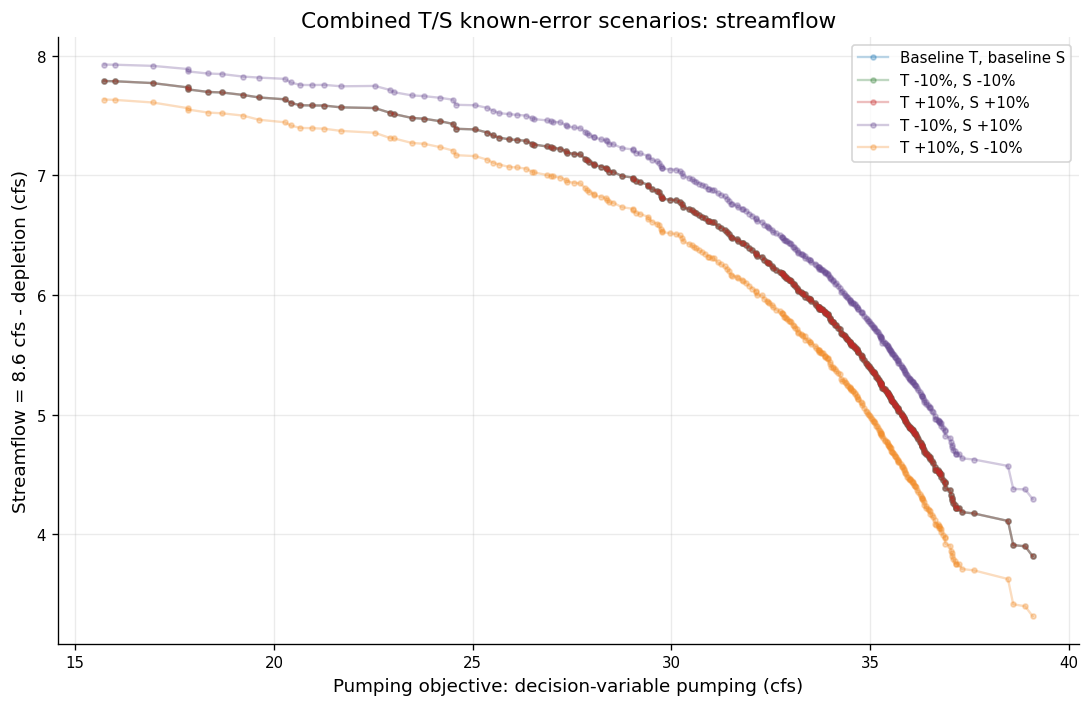

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_pumping_vs_streamflow.png


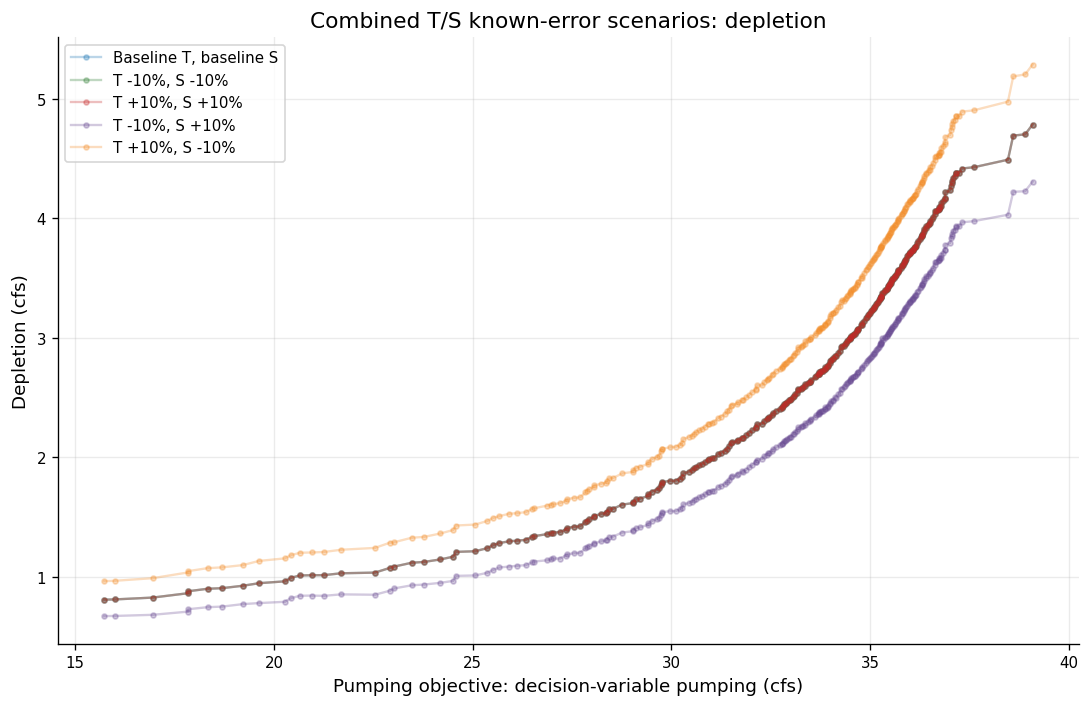

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_pumping_vs_depletion.png


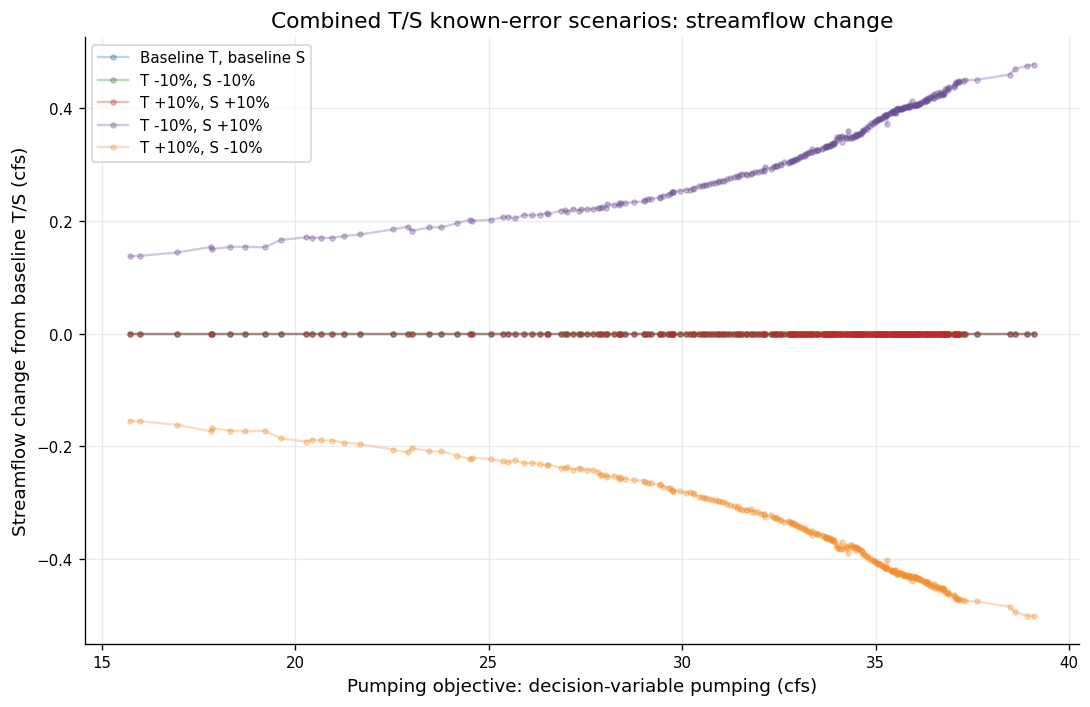

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_streamflow_change_vs_pumping.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_pumping_vs_streamflow.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_pumping_vs_depletion.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_streamflow_change_vs_pumping.png


In [ ]:
plot_df = up.sort_for_plot(results_with_changes, xcol=up.PUMPING_COLUMN_FOR_HYDRO_PLOTS)

scenario_colors = {
    "baseline_T1_S1": "#1F77B4",
    "Tlow_Slow": "#2E7D32",
    "Thigh_Shigh": "#C62828",
    "Tlow_Shigh": "#6A4C93",
    "Thigh_Slow": "#F28E2B",
}

def plot_combined_front(y_col, y_label, title, outfile):
    fig, ax = plt.subplots(figsize=(9.2, 6.0))
    for scenario in scenario_order:
        g = plot_df.loc[plot_df["scenario"] == scenario].copy()
        if g.empty:
            continue
        ax.plot(
            g[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            g[y_col],
            marker="o",
            markersize=3,
            linewidth=1.4,
            label=str(g["scenario_label"].iloc[0]),
            color=scenario_colors.get(scenario, None),
            alpha=0.3,
        )
    ax.set_xlabel("Pumping objective: decision-variable pumping (cfs)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(loc="best")
    up.save_figure(fig, outfile)

streamflow_fig = OUTPUT_DIR / "301b_combined_T_storage_pumping_vs_streamflow.png"
depletion_fig = OUTPUT_DIR / "301b_combined_T_storage_pumping_vs_depletion.png"
change_fig = OUTPUT_DIR / "301b_combined_T_storage_streamflow_change_vs_pumping.png"

plot_combined_front(
    y_col="streamflow_cfs",
    y_label="Streamflow = 8.6 cfs - depletion (cfs)",
    title="Combined T/S known-error scenarios: streamflow",
    outfile=streamflow_fig,
)

plot_combined_front(
    y_col="depletion_cfs",
    y_label="Depletion (cfs)",
    title="Combined T/S known-error scenarios: depletion",
    outfile=depletion_fig,
)

plot_combined_front(
    y_col="streamflow_change_from_baseline_cfs",
    y_label="Streamflow change from baseline T/S (cfs)",
    title="Combined T/S known-error scenarios: streamflow change",
    outfile=change_fig,
)

print("Saved:", streamflow_fig)
print("Saved:", depletion_fig)
print("Saved:", change_fig)


## 9. Plot interaction effects

These figures show whether the combined T/S response is close to the sum of the individual T-only and S-only responses.


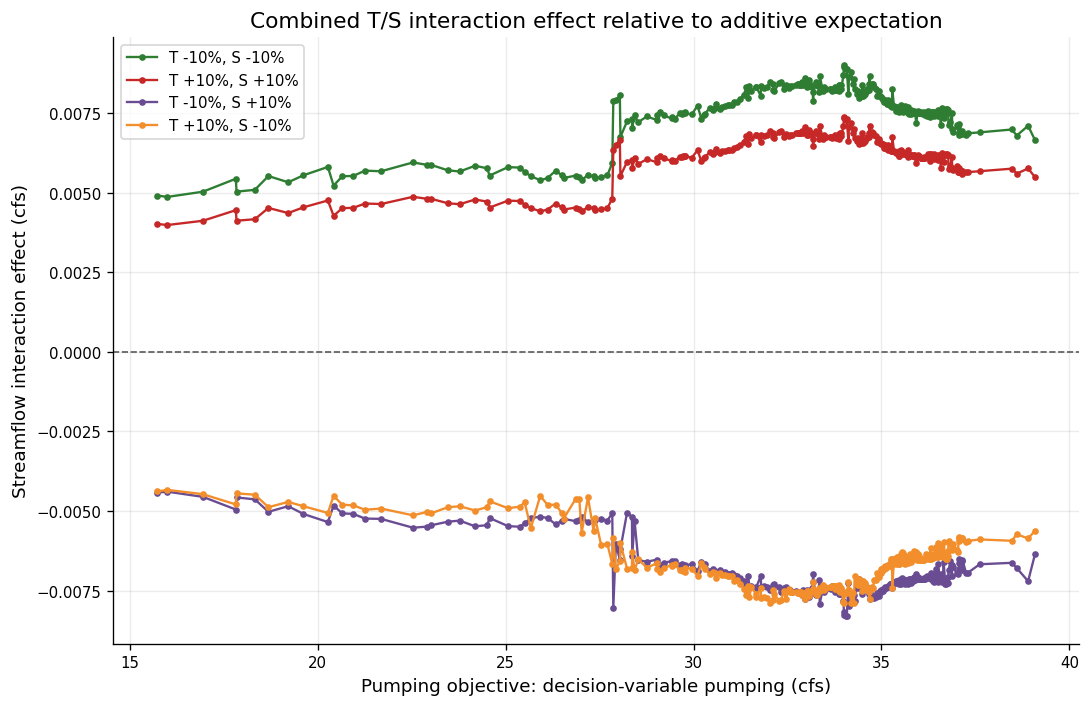

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_streamflow_interaction_effect_vs_pumping.png


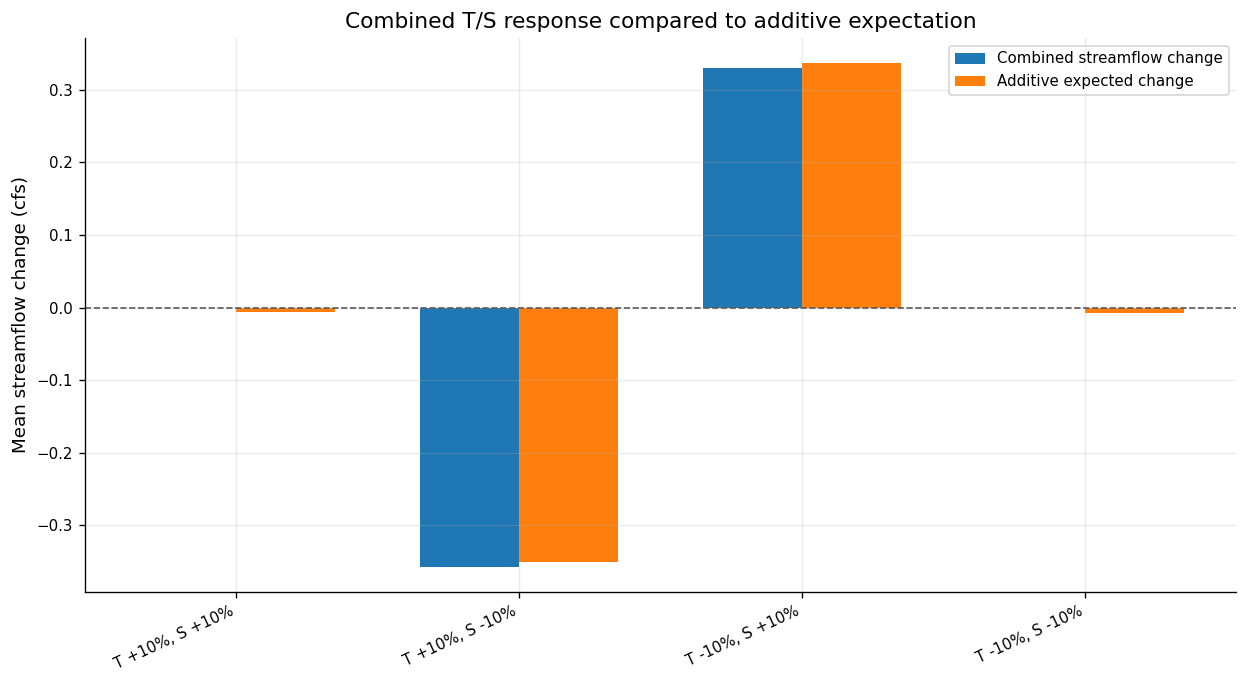

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_mean_effects_and_interactions.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_streamflow_interaction_effect_vs_pumping.png
Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301b_combined_T_storage_known_error_depletion_q/301b_combined_T_storage_mean_effects_and_interactions.png


In [ ]:
interaction_plot_df = up.sort_for_plot(interaction_results, xcol=up.PUMPING_COLUMN_FOR_HYDRO_PLOTS)

interaction_fig = OUTPUT_DIR / "301b_streamflow_interaction_effect_vs_pumping.png"
fig, ax = plt.subplots(figsize=(9.2, 6.0))

for scenario in scenario_order:
    if scenario == baseline_scenario:
        continue
    g = interaction_plot_df.loc[interaction_plot_df["scenario"] == scenario].copy()
    if g.empty:
        continue
    ax.plot(
        g[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS],
        g["streamflow_interaction_effect_cfs"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        label=str(g["scenario_label"].iloc[0]),
        color=scenario_colors.get(scenario, None),
    )

ax.axhline(0, color="0.35", linestyle="--", linewidth=1.0)
ax.set_xlabel("Pumping objective: decision-variable pumping (cfs)")
ax.set_ylabel("Streamflow interaction effect (cfs)")
ax.set_title("Combined T/S interaction effect relative to additive expectation")
ax.legend(loc="best")
up.save_figure(fig, interaction_fig)

bar_fig = OUTPUT_DIR / "301b_combined_T_storage_mean_effects_and_interactions.png"
bar_df = interaction_summary.loc[interaction_summary["scenario"] != baseline_scenario].copy()
x = np.arange(len(bar_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.bar(x - width / 2, bar_df["mean_combined_streamflow_change_cfs"], width, label="Combined streamflow change")
ax.bar(x + width / 2, bar_df["mean_additive_expected_streamflow_change_cfs"], width, label="Additive expected change")
ax.axhline(0, color="0.35", linestyle="--", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(bar_df["scenario_label"], rotation=25, ha="right")
ax.set_ylabel("Mean streamflow change (cfs)")
ax.set_title("Combined T/S response compared to additive expectation")
ax.legend(loc="best")
up.save_figure(fig, bar_fig)

print("Saved:", interaction_fig)
print("Saved:", bar_fig)


## 10. Write a short Markdown results summary

In [ ]:
def fmt(value, ndigits=6):
    if pd.isna(value):
        return "NA"
    return f"{float(value):.{ndigits}f}"

summary_lines = []
for _, row in scenario_summary.iterrows():
    summary_lines.append(
        f"| {row['scenario_label']} | {row['T_factor']:.1f} | {row['S_factor']:.1f} | {row['mean_streamflow_change_from_baseline_cfs']:.6f} | {row['max_absolute_streamflow_error_cfs']:.6f} | {row['mean_streamflow_shortfall_below_baseline_cfs']:.6f} |"
    )

interaction_lines = []
for _, row in interaction_summary.loc[interaction_summary["scenario"] != baseline_scenario].iterrows():
    interaction_lines.append(
        f"| {row['scenario_label']} | {row['mean_combined_streamflow_change_cfs']:.6f} | {row['mean_additive_expected_streamflow_change_cfs']:.6f} | {row['mean_streamflow_interaction_effect_cfs']:.6f} | {row['max_abs_streamflow_interaction_effect_cfs']:.6f} |"
    )

summary_text = f"""# 301b Combined T/S Known-Error Interaction Summary

## Purpose

This notebook evaluated how the baseline depletion-q Pareto pumping designs respond when transmissivity (T) and storage (S) are perturbed together.

The goal is to determine whether the combined T/S response is approximately additive or whether there is an interaction effect.

## Combined scenario results

| Scenario | T factor | S factor | Mean streamflow change (cfs) | Max absolute streamflow error (cfs) | Mean streamflow shortfall (cfs) |
|---|---:|---:|---:|---:|---:|
{chr(10).join(summary_lines)}

## Interaction analysis

Interaction effect is calculated as:

interaction effect = combined streamflow change - (T-only streamflow change + S-only streamflow change)

| Scenario | Mean combined streamflow change (cfs) | Mean additive expected change (cfs) | Mean interaction effect (cfs) | Max abs interaction effect (cfs) |
|---|---:|---:|---:|---:|
{chr(10).join(interaction_lines)}

## Interpretation guide

- Interaction near zero means T and S effects are mostly additive.
- Positive interaction means the combined case gives higher streamflow than the additive expectation.
- Negative interaction means the combined case gives lower streamflow than the additive expectation, which is the management-risk direction.

## Main use

This notebook helps connect parameter uncertainty to robust decision-making. If the worst combined T/S cases produce substantially larger streamflow shortfalls than either parameter alone, then a robust pumping plan should be evaluated under combined uncertainty, not only one-parameter-at-a-time uncertainty.
"""

summary_path = OUTPUT_DIR / "301b_combined_T_storage_results_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("Saved:", summary_path)


# 301b Combined T/S Known-Error Interaction Summary

## Purpose

This notebook evaluated how the baseline depletion-q Pareto pumping designs respond when transmissivity (T) and storage (S) are perturbed together.

The goal is to determine whether the combined T/S response is approximately additive or whether there is an interaction effect.

## Combined scenario results

| Scenario | T factor | S factor | Mean streamflow change (cfs) | Max absolute streamflow error (cfs) | Mean streamflow shortfall (cfs) |
|---|---:|---:|---:|---:|---:|
| T +10%, S +10% | 1.1 | 1.1 | -0.000000 | 0.000000 | 0.000000 |
| T +10%, S -10% | 1.1 | 0.9 | -0.356789 | 0.501979 | 0.356789 |
| T -10%, S +10% | 0.9 | 1.1 | 0.329571 | 0.477856 | 0.000000 |
| T -10%, S -10% | 0.9 | 0.9 | -0.000000 | 0.000000 | 0.000000 |
| Baseline T, baseline S | 1.0 | 1.0 | 0.000000 | 0.000000 | 0.000000 |

## Interaction analysis

Interaction effect is calculated as:

interaction effect = combined streamflow change - (T-only strea

## 11. List final outputs

In [ ]:
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)


301b_combined_T_storage_interaction_member_results.csv
301b_combined_T_storage_interaction_missing_matches.csv
301b_combined_T_storage_interaction_summary.csv
301b_combined_T_storage_mean_effects_and_interactions.png
301b_combined_T_storage_pumping_vs_depletion.png
301b_combined_T_storage_pumping_vs_streamflow.png
301b_combined_T_storage_reevaluation_long.csv
301b_combined_T_storage_reevaluation_wide.csv
301b_combined_T_storage_results_summary.md
301b_combined_T_storage_scenario_summary.csv
301b_combined_T_storage_streamflow_change_vs_pumping.png
301b_streamflow_interaction_effect_vs_pumping.png
